In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the dataset
new_file_path = 'Diabetes_prediction.csv'
data = pd.read_csv(new_file_path)

NameError: name 'head' is not defined

In [21]:

# Select features and target variable
X = data[['Glucose', 'Age']]  # Features (Glucose and Age)
y = data['Diagnosis']  # Target variable (Diagnosis)

In [23]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)  # Fit the model

# Predicting the test set results
y_pred = log_reg.predict(X_test)

In [27]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the model: {:.2f}%".format(accuracy * 100))

Confusion Matrix:
 [[137   0]
 [ 63   0]]
Accuracy of the model: 68.50%


->The model exhibits severe bias since it solely predicts the negative class in every situation.
->The model performs poorly because it is completely unable to identify affirmative cases, even with an accuracy of 68.50%.
->With 137 negative and 63 positive cases in the test set, there's probably a class imbalance problem.
->The model misses all 63 positive examples and obtains 0% recall for the positive class.
->To effectively handle both classes, this model needs major modifications and is not fit for deployment.

###Since our issue is to predict a binary result (whether or not someone has diabetes, denoted as 0 or 1 in the Diagnosis column), logistic regression is being used instead of linear regression.
For a binary classification problem such as this one, linear regression is not appropriate since it predicts continuous numerical values.
In contrast, logistic regression is specifically meant for jobs involving classification. It makes a prediction about the likelihood of an event (in this case, the likelihood of acquiring diabetes) and then divides the outcome into two groups (0 and 1).

In [31]:
# Logistic Regression Coefficients
coefficients = log_reg.coef_
intercept = log_reg.intercept_
print("Logistic Regression Coefficients:\n", coefficients)
print("Intercept:\n", intercept)

Logistic Regression Coefficients:
 [[-0.00406224 -0.01342934]]
Intercept:
 [0.14941842]


Small negative coefficients in the logistic regression model (-0.00406224 and -0.01342934) for both features indicate weak inverse correlations with the likelihood of the positive class. Because its absolute coefficient is bigger, the second feature has a marginally stronger influence. When all characteristics are zero, the positive intercept (0.14941842) indicates a little bias towards the positive class. The minimal size of these coefficients, however, suggests that the characteristics may not have much predictive potential or that the model may be underfit, which could account for the earlier observed poor performance.

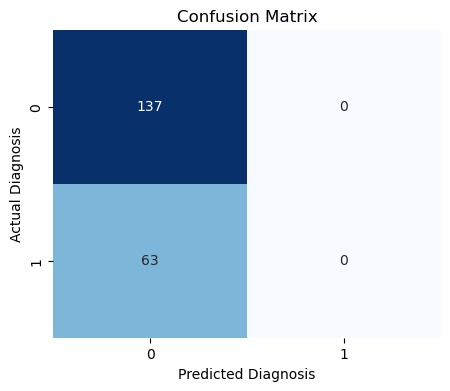

In [15]:
# Plot the Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

This representation of the confusion matrix gives a clear sense of the model's performance:
1. Model Bias: There is a strong bias towards the negative class as the model only predicts one class (class 0) in every occurrence.
2.True Negatives: The top-left cell contains 137 true negatives, or negative cases that were accurately predicted.
3. False Negatives: The model misclassified 63 positive cases as negative, as evidenced by the 63 false negatives displayed in the bottom-left cell.
4.No Positive Predictions: The model did not predict any positive cases, as seen by the zeros in the right-side cells (0, 1) and (1, 1).

The model performs poorly, as this picture demonstrates, especially in its total inability to find any positive situations. With its constant output of the negative class, the model is effectively acting as a constant predictor, independent of the input. This implies that there are significant problems with the model itself, the training procedure, or perhaps the caliber or distribution of the training data. This model needs to be significantly improved before it can be used in any real-world situation.